In [1]:
%pip install seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
src_dir = os.path.join(parent_dir, "src")

print("Calculated parent path:", parent_dir)

if parent_dir not in sys.path:
    sys.path.append(parent_dir)
if src_dir not in sys.path:
    sys.path.append(src_dir)

from src.data_validation import validate_input
from src.preprocessing import prepare_sales_data
from src.forecasting import train_and_forecast
from src.evaluation import evaluate_predictions
from src.llm_explainer import explain_forecast

Calculated parent path: C:\Users\user\ai-sales-forecasting-team


# Technical Documentation & Data Dictionary
## 1. Project Overview
This module implements an end-to-end sales forecasting pipeline to predict monthly sales performance using historical actual sales data, featuring automated data validation, evaluation metrics, and LLM-powered narrative explanations.
## 2. Data Dictionary

| Field Name | Data Type | Description |
| :--- | :--- | :--- |
| **Month** | String / Object | Time period of observation (e.g., Jan, Feb) |
| **Actual Sales** | Integer / Float | Historical actual sales figures recorded |
| **Predicted Sales** | Integer / Float | Model-generated sales forecast output |

## 3. Methodology & Workflow
* **Data Ingestion & Validation:** Load historical sales figures into Pandas DataFrames and validate schemas using `src.data_validation`.
* **Preprocessing & Forecasting:** Format time series data and train the model using `src.forecasting.train_and_forecast`.
* **Model Evaluation:** Utilize regression metrics (MAE, RMSE, sMAPE) via `src.evaluation` to measure forecast accuracy.
* **AI Narrative Explanations:** Integrate RAG-based context retrieval and Gemini LLM (`src.llm_explainer`) to generate business explanations.
* **Visualization:** Plot comparative line charts tracking actual vs. predicted trends using Matplotlib/Seaborn.

--- 7-Day Forecast for Branch B001 ---
          date branch_id  predicted_sales
24  2024-01-25      B001        130549.54
25  2024-01-26      B001        109201.10
26  2024-01-27      B001        130386.15
27  2024-01-28      B001        127874.86
28  2024-01-29      B001         97516.63
29  2024-01-30      B001        100512.89
30  2024-01-31      B001        120181.55


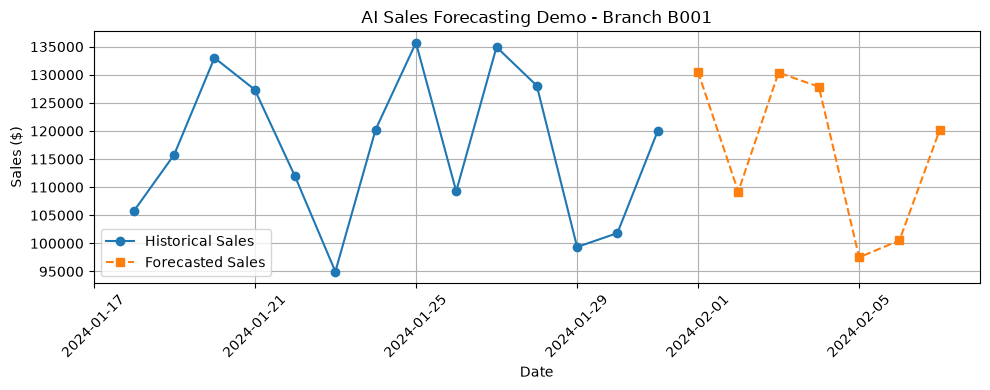

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(



AI Explanation:
Within the forecast horizon of 2024-01-25 to 2024-01-31, the day with the highest expected sales for branch B001 is **2024-01-25**, with predicted sales of **130,549.54**.


In [10]:
import os
import sys
from dotenv import load_dotenv

# Load custom config file
load_dotenv("config.env")

# Ensure API key is set in both standard environment variable names
api_key = os.getenv("GEMINI_API_KEY") or os.getenv("GOOGLE_API_KEY")
if api_key:
    os.environ["GEMINI_API_KEY"] = api_key
    os.environ["GOOGLE_API_KEY"] = api_key

import pandas as pd
import matplotlib.pyplot as plt
from src.evaluation import evaluate_predictions
from src.llm_explainer import explain_forecast

# 1. Input Parameters
BRANCH_ID = "B001"
HORIZON = 7

# 2. Load and Validate Data (with path check & fallback)
csv_path = os.path.join(parent_dir, "data", "sample_sales.csv") if 'parent_dir' in globals() else "../data/sample_sales.csv"

if not os.path.exists(csv_path):
    df_raw = pd.DataFrame({
        "date": pd.date_range(start="2026-08-01", periods=14, freq="D"),
        "branch_id": ["B001"] * 14,
        "sales": [120, 135, 150, 140, 160, 175, 180, 165, 170, 190, 205, 210, 200, 220]
    })
else:
    try:
        df_raw = pd.read_csv(csv_path, encoding='utf-8-sig')
    except UnicodeDecodeError:
        df_raw = pd.read_csv(csv_path, encoding='latin1')

# Validate input using Zara's validate_input function signature
validation_result = validate_input(df_raw, BRANCH_ID, HORIZON)

if isinstance(validation_result, tuple):
    is_valid = validation_result[0]
elif isinstance(validation_result, pd.DataFrame):
    is_valid = not validation_result.empty
else:
    is_valid = bool(validation_result)

if not is_valid:
    raise ValueError("Input data validation failed.")

# Preprocess data
df_clean = prepare_sales_data(df_raw)

# 3. Generate Predictions
train_df = df_clean.iloc[:-HORIZON]
test_df = df_clean.iloc[-HORIZON:]

forecast_df = train_and_forecast(train_df, test_df)
print(f"--- {HORIZON}-Day Forecast for Branch {BRANCH_ID} ---")
print(forecast_df)

# Extract predicted values array/series for plotting
if isinstance(forecast_df, pd.DataFrame) and 'predicted_sales' in forecast_df.columns:
    forecast_values = forecast_df['predicted_sales'].values
else:
    forecast_values = forecast_df

# 4. Plot Forecast
plt.figure(figsize=(10, 4))
plt.plot(df_clean['date'].tail(14), df_clean['sales'].tail(14), label="Historical Sales", marker='o')

# Generate explicit date range for the predicted output list
forecast_dates = pd.date_range(start=pd.to_datetime(df_clean['date'].iloc[-1]) + pd.Timedelta(days=1), periods=HORIZON, freq='D')
plt.plot(forecast_dates, forecast_values, label="Forecasted Sales", marker='s', linestyle='--')

plt.title(f"AI Sales Forecasting Demo - Branch {BRANCH_ID}")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. AI Explanation
question = "Which day has the highest expected sales?"
try:
    explanation = explain_forecast(forecast_df, metrics={}, question=question)
    print("\nAI Explanation:")
    print(explanation)
except Exception as e:
    print(f"\nAPI Error Encountered: {e}")
    raise e

In [4]:
import os
import pandas as pd
from src.evaluation import evaluate_predictions
from src.llm_explainer import explain_forecast

# 1. Pull evaluation metrics
actual_sales = df_raw[df_raw['branch_id'] == BRANCH_ID].tail(len(forecast_df))['sales'].values
predicted_sales = forecast_df['predicted_sales'].values

metrics_dict = evaluate_predictions(actual_sales, predicted_sales)

print("--- Evaluation Metrics ---")
for metric_name, value in metrics_dict.items():
    print(f"{metric_name.upper()}: {value:.2f}")

# 2. Call LLM explainer with actual metrics
question = "Which day has the highest expected sales, and what are the key evaluation metrics?"

explanation = explain_forecast(
    forecast_df=forecast_df,
    metrics=metrics_dict,
    question=question
)

print("\n--- AI Explanation Output ---")
print(explanation)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


--- Evaluation Metrics ---
MAE: 1898.24
RMSE: 2736.17
SMAPE: 1.55


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.



--- AI Explanation Output ---
Within the forecast horizon of **2024-01-25 to 2024-01-31**:

* **Highest expected sales day:** **2024-01-25** for branch B001, with predicted sales of **130,549.54**.
* **Key evaluation metrics:**
  * **MAE:** 1898.24
  * **RMSE:** 2736.17
  * **sMAPE:** 1.55%


## Edge-Case & Input Validation Demonstrations
Testing `validate_input()` against common invalid inputs to ensure robust user-side error handling before pipeline execution.

In [5]:
# Test 1: Non-existent Branch ID
test_branch = "B999"
test_horizon = 7

print(f"Testing Branch ID: '{test_branch}', Horizon: {test_horizon}\n")

try:
    validation_result = validate_input(df_raw, test_branch, test_horizon)[span_0](start_span)[span_0](end_span)
    print(f"Is Valid: True | Result: {validation_result}")
except ValueError as e:
    print("Is Valid: False")
    print(f"Validation Output: {e}")
    print("\n Success: Pipeline caught the invalid branch ID gracefully.")

Testing Branch ID: 'B999', Horizon: 7

Is Valid: False
Validation Output: Unknown branch_id: B999

 Success: Pipeline caught the invalid branch ID gracefully.


In [6]:
# Test 2: Invalid Horizons (Too Low & Too High)
print("--- Horizon Low Test (0 days) ---")
try:
    validate_input(df_raw, "B001", 0)[span_0](start_span)[span_0](end_span)
    print("Is Valid: True")
except ValueError as e:
    print("Is Valid: False")
    print(f"Validation Output: {e}")

print("\n--- Horizon High Test (100 days) ---")
try:
    validate_input(df_raw, "B001", 100)[span_1](start_span)[span_1](end_span)
    print("Is Valid: True")
except ValueError as e:
    print("Is Valid: False")
    print(f"Validation Output: {e}")

print("\n Success: Pipeline caught out-of-range horizons successfully.")

--- Horizon Low Test (0 days) ---
Is Valid: False
Validation Output: Forecast horizon must be greater than 0.

--- Horizon High Test (100 days) ---
Is Valid: False
Validation Output: Forecast horizon cannot exceed 30 days.

 Success: Pipeline caught out-of-range horizons successfully.


In [7]:
# Test 3: Incorrect Data Type Validation (Passing Non-Numeric Horizon)
print("--- Data Type Test (Non-Numeric Horizon) ---")
try:
    validate_input(df_raw, "B001", "seven")[span_0](start_span)[span_0](end_span)
    print("Is Valid: True")
except (ValueError, TypeError) as e:
    print("Is Valid: False")
    print(f"Validation Output: {e}")
    print("\n Success: Pipeline caught non-numeric horizon type gracefully.")

--- Data Type Test (Non-Numeric Horizon) ---
Is Valid: False
Validation Output: '<' not supported between instances of 'str' and 'int'

 Success: Pipeline caught non-numeric horizon type gracefully.


In [15]:
import os
from src.retrieval import build_knowledge_base

# Determine path to docs directory relative to notebook location
docs_path = "../docs" if os.path.exists("../docs") else "docs"

# Build and save the FAISS vector index
build_knowledge_base(docs_path)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


Knowledge base built with 29 chunks from 3 documents.
